# Imported required libraries

In [224]:
# Data Handling & System Utilities
import os
import random
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import string
import kaggle as kg
from dotenv import load_dotenv
import time
import pickle

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import (FuncFormatter, MaxNLocator, PercentFormatter)
import seaborn as sns
import missingno as msno
from IPython.display import (HTML, Markdown, display)

# Interactive visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [225]:
# Statistical analysis and Hypothesis testing
from scipy import stats
from scipy.stats import (gamma, ks_2samp)
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from scipy.stats import norm
from numpy.linalg import matrix_rank

# Machine learning & Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import (LinearRegression, LogisticRegression)
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, 
    classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error,
    mean_squared_error, r2_score)
from scipy.stats import ks_2samp
from sklearn.utils.class_weight import compute_class_weight
from yellowbrick.target import ClassBalance

In [226]:
# Display settings & Warning configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Reset to default after use (recommended practice)
# pd.reset_option('display.max_columns')
import warnings
warnings.filterwarnings("ignore")

# Importing data

In [227]:
# Define the deployment directory and file name
# --------------------------------------------------------------------------------------
model_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\lending_club_data"
holdout_filename = "lending_club_holdout_2017_2018.csv"  # Ensure this matches your 'holdout_csv_path' filename
full_holdout_path = os.path.join(model_directory, holdout_filename)

# Load the data
# --------------------------------------------------------------------------------------
if os.path.exists(full_holdout_path):
    # 'compression' utilizes gzip decompression on the fly
    # 'low_memory=False' ensures pandas handles mixed data type inferences efficiently
    df_holdout = pd.read_csv(full_holdout_path, compression='gzip', low_memory=False)
    
    print("=" * 100)
    print("✅ HOLDOUT SET SUCCESSFULLY DEPLOYED & LOADED")
    print("=" * 100)
    print(f"• Total Independent Records : {len(df_holdout):,}")
    print(f"• Total Data Features/Columns: {df_holdout.shape[1]}")
    print("-" * 100)
    
    # Quick structural check to ensure 'id' is tracked safely as a string
    df_holdout['id'] = df_holdout['id'].astype(str)
    
    # Display the first few rows to verify structural integrity
    display(df_holdout.head())
    
else:
    print(f"❌ Abort: Could not locate the compressed holdout file at:\n{full_holdout_path}")
    print("👉 Please execute Section 2 in your primary data pipeline notebook first!")

✅ HOLDOUT SET SUCCESSFULLY DEPLOYED & LOADED
• Total Independent Records : 50,000
• Total Data Features/Columns: 152
----------------------------------------------------------------------------------------------------


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,issue_d_parsed
0,96240406,NaN,12000.00,12000.00,12000.00,60 months,13.49,276.06,C,C2,Sr. Parole Agent,10+ years,MORTGAGE,95000.00,Not Verified,Jan-2017,Current,n,https://lendingclub.com/browse/loanDetail.action?loan_id=96240406,NaN,other,Other,617xx,IL,26.86,0.00,Apr-1998,775.00,779.00,0.00,NaN,NaN,20.00,0.00,10974.00,20.30,38.00,f,7764.57,7764.57,7168.57,7168.57,4235.43,2933.14,0.00,0.00,0.00,Mar-2019,276.06,Apr-2019,Mar-2019,799.00,795.00,0.00,NaN,1.00,Individual,NaN,NaN,NaN,0.00,0.00,385463.00,0.00,11.00,1.00,7.00,8.00,161554.00,91.00,0.00,1.00,5868.00,74.00,54100.00,2.00,1.00,3.00,8.00,19273.00,42162.00,18.00,0.00,0.00,167.00,225.00,13.00,8.00,5.00,43.00,NaN,8.00,NaN,0.00,2.00,3.00,6.00,11.00,19.00,7.00,14.00,3.00,20.00,0.00,0.00,0.00,1.00,100.00,0.00,0.00,0.00,461434.00,172528.00,51400.00,178534.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,2017-01-01
1,96847060,NaN,12000.00,12000.00,12000.00,36 months,11.44,395.37,B,B4,Teacher,10+ years,MORTGAGE,50000.00,Verified,Jan-2017,Current,n,https://lendingclub.com/browse/loanDetail.action?loan_id=96847060,NaN,other,Other,463xx,IN,27.48,2.00,Dec-1990,685.00,689.00,2.00,10.00,NaN,9.00,0.00,9593.00,70.00,26.00,f,3754.05,3754.05,10271.99,10271.99,8245.95,2026.04,0.00,0.00,0.00,Mar-2019,395.37,Apr-2019,Mar-2019,679.00,675.00,0.00,18.00,1.00,Individual,NaN,NaN,NaN,0.00,153.00,31841.00,2.00,3.00,1.00,1.00,5.00,22248.00,56.00,1.00,1.00,7860.00,60.00,13700.00,0.00,0.00,3.00,2.00,3538.00,2394.00,78.40,0.00,0.00,313.00

# Importing the model

In [228]:
# Deployment directory
# -----------------------------------------------------------------------------------------------
deployment_dir = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"

In [229]:
# Load PD model
# -----------------------------------------------------------------------------------------------
model_directory = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"
model_filename = "credit_risk_pd_model.pkl"
full_model_path = os.path.join(model_directory, model_filename)

with open(os.path.join(deployment_dir, "credit_risk_pd_model.pkl"), "rb") as file:
    pd_artifacts = pickle.load(file)

# View what had been saved in the model
print(pd_artifacts.keys())

pd_model = pd_artifacts["model"]
pd_calibration_model = pd_artifacts["calibration_model"]
pd_threshold = pd_artifacts["optimal_threshold"]
pd_features = pd_artifacts["feature_names"]
pd_roc = pd_artifacts["roc_auc"]
pd_f1 = pd_artifacts["f1_score"]
pd_recall = pd_artifacts["recall"]
pd_precision = pd_artifacts["precision"]

print('✅ PD model loaded successfully')
print(f"Number of Features: {len(pd_features)}")

dict_keys(['model', 'calibration_model', 'optimal_threshold', 'factor', 'offset', 'target_score', 'target_odds', 'pdo', 'min_score', 'max_score', 'feature_names', 'roc_auc', 'f1_score', 'recall', 'precision'])
✅ PD model loaded successfully
Number of Features: 84


In [230]:
# Load LGD Model
# -----------------------------------------------------------------------------------------------
with open(os.path.join(deployment_dir, "credit_risk_lgd_model.pkl"), "rb") as file:
    lgd_artifacts = pickle.load(file)

# View what had been saved in the model
print(lgd_artifacts.keys())

lgd_stage1_model = lgd_artifacts["stage1_model"]
lgd_optimal_threshold = lgd_artifacts["stage1_optimal_threshold"]
lgd_stage2_model = lgd_artifacts["stage2_model"]
lgd_stage1_features = lgd_artifacts["stage1_feature_names"]
lgd_stage2_features = lgd_artifacts["stage2_feature_names"]
lgd_mae = lgd_artifacts["MAE"]
lgd_mse = lgd_artifacts["MSE"]
lgd_rmse = lgd_artifacts["RMSE"]
ead_mae = lgd_artifacts["EAD_MAE"]
ead_rmse = lgd_artifacts["EAD_RMSE"]

print("✅ LGD model loaded successfully")
print(f"Number of Features: {len(lgd_stage1_features)}")

dict_keys(['stage1_model', 'stage1_optimal_threshold', 'stage2_model', 'stage1_feature_names', 'stage2_feature_names', 'stage1_roc_auc', 'stage2_rmse', 'stage2_r2', 'MAE', 'MSE', 'RMSE', 'EAD_MAE', 'EAD_RMSE'])
✅ LGD model loaded successfully
Number of Features: 44


In [231]:
# Load EAD Model
# -----------------------------------------------------------------------------------------------
with open(os.path.join(deployment_dir, "credit_risk_ead_model.pkl"), "rb") as file:
    ead_artifacts = pickle.load(file)

# View what had been saved in the model
print(ead_artifacts.keys())

ead_model = ead_artifacts["ead_model"]
ead_features = ead_artifacts["ead_feature_names"]

print("✅ EAD model loaded successfully")
print(f"Number of Features: {len(ead_features)}")

dict_keys(['ead_model', 'ead_feature_names'])
✅ EAD model loaded successfully
Number of Features: 44


# Data Processing

In [232]:
df_holdout['issue_d_parsed'] = pd.to_datetime(df_holdout['issue_d'], format='%b-%Y', errors='coerce')
df_holdout = df_holdout.sort_values(by='issue_d_parsed', ascending=True).reset_index(drop=True)

In [233]:
# Ensure the grade order is correct for analysis and visualization
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grade_order = [f"{letter}{num}" for letter in grade_order for num in range(1, 6)]

# Apply the ordered categorical data types to the DataFrame
df_holdout['grade'] = pd.Categorical(df_holdout['grade'], categories=grade_order, ordered=True)
df_holdout['sub_grade'] = pd.Categorical(df_holdout['sub_grade'], categories=sub_grade_order, ordered=True)

# Verify the full generated list
print("Generated Subgrade Order List:")
print(sub_grade_order)

Generated Subgrade Order List:
['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']


In [234]:
# Inspect unique values before conversion
print("Original unique values:")
print(df_holdout['emp_length'].unique())

# Convert 'emp_length' (employment length string) to an integer
df_holdout['emp_length']= df_holdout['emp_length'].str.replace('+ years','')
df_holdout['emp_length']= df_holdout['emp_length'].str.replace('< 1 year',str(0))
df_holdout['emp_length']= df_holdout['emp_length'].str.replace('n/a',str(0))
df_holdout['emp_length']= df_holdout['emp_length'].str.replace(' years','')
df_holdout['emp_length']= df_holdout['emp_length'].str.replace(' year','')

# Compute the most frequent employment length category
most_frequent_emp = df_holdout['emp_length'].mode(dropna=True)[0]

# Replace missing values with the mode
df_holdout['emp_length'] = df_holdout['emp_length'].fillna(most_frequent_emp)

# Verification
print("Missing values after imputation:")
print(df_holdout['emp_length'].isna().sum())

Original unique values:
['10+ years' '9 years' '4 years' '< 1 year' nan '1 year' '2 years'
 '3 years' '6 years' '5 years' '7 years' '8 years']
Missing values after imputation:
0


In [235]:
# Define the logical employment length order
emp_order = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Convert to ordered numerical type
df_holdout['emp_length'] = pd.to_numeric(df_holdout['emp_length'], errors='coerce')

# Preview the converted data
print("\nValue counts (sorted):")
display(df_holdout['emp_length'].value_counts().sort_index())


Value counts (sorted):


emp_length
0      4599
1      3333
2      4556
3      4052
4      3109
5      3032
6      2178
7      1857
8      1558
9      1472
10    20254
Name: count, dtype: int64

In [236]:
# Convert 'earliest_cr_line' using %Y for 4-digit years and handle anomalies safely
df_holdout['earliest_cr_line_date'] = pd.to_datetime(df_holdout['earliest_cr_line'], format='%b-%Y')

# Define anchor baseline date
baseline_date = pd.to_datetime('2019-04-30')

# Calculate the exact difference in months mathematically:
# (Baseline Year - Credit Line Year) * 12 + (Baseline Month - Credit Line Month)
df_holdout['mths_since_earliest_cr_line'] = (
    (baseline_date.year - df_holdout['earliest_cr_line_date'].dt.year) * 12 +
    (baseline_date.month - df_holdout['earliest_cr_line_date'].dt.month))

# Check the descriptive statistics
display(df_holdout['mths_since_earliest_cr_line'].describe())

count   50000.00
mean      211.27
std        95.04
min        41.00
25%       150.00
50%       192.00
75%       259.00
max       819.00
Name: mths_since_earliest_cr_line, dtype: float64

In [237]:
# Calculate the exact difference in months mathematically:
# (Baseline Year - Credit Line Year) * 12 + (Baseline Month - Credit Line Month)
df_holdout['mths_since_issue_d'] = (
    (baseline_date.year - df_holdout['issue_d_parsed'].dt.year) * 12 +
    (baseline_date.month - df_holdout['issue_d_parsed'].dt.month))

# Check the descriptive statistics
display(df_holdout['mths_since_issue_d'].describe())

count   50000.00
mean       14.95
std         6.81
min         4.00
25%         9.00
50%        15.00
75%        21.00
max        27.00
Name: mths_since_issue_d, dtype: float64

In [238]:
# CCF proxy calculation
df_holdout['CCF'] = (df_holdout['funded_amnt'] - df_holdout['total_rec_prncp']) / df_holdout['funded_amnt']
df_holdout['CCF'].describe()

count   50000.00
mean        0.59
std         0.33
min         0.00
25%         0.42
50%         0.72
75%         0.86
max         1.00
Name: CCF, dtype: float64

In [239]:
# Create a binary target variable format
target_mapping = {
    'Current': 0, 'Fully Paid': 0, 'In Grace Period': 0, 'Late (16-30 days)': 0,
    'Late (31-120 days)': 1, 'Charged Off': 1, 'Default': 1}

# Create the new binary target column
df_holdout['target'] = df_holdout['loan_status'].map(target_mapping)

# Display the new distribution to verify class imbalance
print("Target Variable Distribution:")
print(df_holdout['target'].value_counts())
print(df_holdout['target'].value_counts(normalize=True) * 100)

Target Variable Distribution:
target
0    46615
1     3385
Name: count, dtype: int64
target
0   93.23
1    6.77
Name: proportion, dtype: float64


In [240]:
# Calculate mean FICO score from the low and high range columns
df_holdout['fico_mean'] = ((df_holdout['fico_range_low'] + df_holdout['fico_range_high']) / 2).round().astype(int)

# Display the result
display(df_holdout[['fico_range_low', 'fico_range_high', 'fico_mean']].head())

,fico_range_low,fico_range_high,fico_mean
0,775.00,779.00,777
1,725.00,729.00,727
2,665.00,669.00,667
3,700.00,704.00,702
4,720.00,724.00,722


In [241]:
# Combine 'ANY' and 'NONE' into a single category: 'OTHER'
df_holdout['home_ownership'] = df_holdout['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'})

# Verify updated counts
df_holdout['home_ownership'].value_counts()

home_ownership
MORTGAGE    24222
RENT        19745
OWN          5995
OTHER          38
Name: count, dtype: int64

In [242]:
# Calculate recovery rate (recoveries as a proportion of loan principal)
df_holdout['recovery_rate'] = ((df_holdout['recoveries'] - df_holdout['collection_recovery_fee']) / df_holdout['funded_amnt']) * 100
print(df_holdout['recovery_rate'].value_counts())

recovery_rate
0.00     48730
0.51         4
0.68         4
0.41         4
0.82         3
         ...  
10.67        1
11.42        1
16.21        1
11.73        1
9.76         1
Name: count, Length: 1245, dtype: int64


In [243]:
# Apply qcut to partition the interest rates globally
temp_labels = ['L', 'M', 'H']
df_holdout['int_rate_tier_temp'] = pd.qcut(df_holdout['int_rate'], q=[0, 0.40, 0.80, 1.0], labels=temp_labels, duplicates='drop')

# Group by the temporary tier to find the exact mathematical minimum and maximum rates
range_df = df_holdout.groupby('int_rate_tier_temp', observed=False)['int_rate'].agg(['min', 'max'])

# Creates a clean label lookup map: e.g., 'Low' -> 'Low (5.31% to 11.49%)'
tier_label_map = {
    tier: f"{tier} ({row['min']:.0f} - {row['max']:.0f}%)"
    for tier, row in range_df.iterrows()}

df_holdout['int_rate_tier'] = df_holdout['int_rate_tier_temp'].map(tier_label_map)

# Order the categories correctly so they sort sequentially
ordered_labels = [tier_label_map[t] for t in temp_labels if t in tier_label_map]
df_holdout['int_rate_tier'] = pd.Categorical(df_holdout['int_rate_tier'], categories=ordered_labels, ordered=True)

# Drop the temporary staging column to keep the DataFrame clean
df_holdout = df_holdout.drop(columns=['int_rate_tier_temp'])

# Verification
print("📈 Interest Rate Tier Ranges (Mapped Directly to Labels):")
print("-" * 100)
# Create a quick summary visualization DataFrame
summary_df = pd.DataFrame(list(tier_label_map.values()), columns=['Formatted Rate Tier Label'])
display(summary_df)

print("\n" + "-"* 100 + "\n")
print("📊 Distribution Counts:")
print(df_holdout['int_rate_tier'].value_counts().sort_index())

print("\n" + "-"* 100 + "\n")
print("🔎 Data Sample Preview:")
display(df_holdout[['grade', 'sub_grade', 'int_rate', 'int_rate_tier']].head(10))

📈 Interest Rate Tier Ranges (Mapped Directly to Labels):
----------------------------------------------------------------------------------------------------


,Formatted Rate Tier Label
0,L (5 - 11%)
1,M (11 - 17%)
2,H (17 - 31%)



----------------------------------------------------------------------------------------------------

📊 Distribution Counts:
int_rate_tier
L (5 - 11%)     20202
M (11 - 17%)    20344
H (17 - 31%)     9454
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------

🔎 Data Sample Preview:


,grade,sub_grade,int_rate,int_rate_tier
0,C,C2,13.49,M (11 - 17%)
1,B,B4,11.44,M (11 - 17%)
2,C,C2,13.49,M (11 - 17%)
3,B,B1,8.24,L (5 - 11%)
4,A,A5,7.99,L (5 - 11%)
5,C,C3,13.99,M (11 - 17%)
6,C,C4,14.99,M (11 - 17%)
7,B,B5,11.49,M (11 - 17%)
8,C,C4,14.99,M (11 - 17%)
9,C,C3,13.99,M (11 - 17%)


# Data treatment

In [244]:
# Numeric and Categorical data types classification
# ------------------------------------------------------------------------------
# Select columns with numerical data types (integers, floats) and store their names in a list
numerical_columns = df_holdout.select_dtypes(include=[np.number]).columns.tolist()

# Select columns with object (string/text) or category data types and store their names in a list
categorical_columns = df_holdout.select_dtypes(include=["object", "category"]).columns.tolist()

# Select columns with datetime data types (both timezone-aware and naive) and store their names in a list
datetime_columns = df_holdout.select_dtypes(include=["datetime", "datetime64"]).columns.tolist()

# Count the number of columns in each list
num_numeric = len(numerical_columns)
num_categorical = len(categorical_columns)
num_datetime = len(datetime_columns)
total_columns = num_numeric + num_categorical + num_datetime

# Previews and Outputs
print(f"🔢 Numeric data columns ({num_numeric}): {numerical_columns}\n")
print(f"🔤 Categorical data columns ({num_categorical}): {categorical_columns}\n")
print(f"📅 Datetime data columns ({num_datetime}): {datetime_columns}\n")

print("-" * 100)
print(f"Total columns identified: {total_columns} (out of {df_holdout.shape[1]} columns in DataFrame)")

🔢 Numeric data columns (121): ['member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'desc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'b

In [245]:
# Create a master list of all unique feature names across all 4 modeling tracks
all_model_features = list(set(pd_features + lgd_stage1_features + lgd_stage2_features + ead_features))
# Identify which raw numeric columns are actually required by any model
required_numeric_raw = [col for col in numerical_columns if col in all_model_features]

# Identify which raw text/categorical columns match a dummy prefix expected by a model
required_categorical_raw = [cat_col for cat_col in categorical_columns if any(feat.startswith(cat_col + "_") for feat in all_model_features)]

print("🎯 Filtering out irrelevant columns...")
print(f" -> Retaining {len(required_numeric_raw)} Raw Numeric Columns")
print(f" {required_numeric_raw}\n")
print(f" -> Retaining {len(required_categorical_raw)} Raw Categorical Columns")
print(f" {required_categorical_raw}")

🎯 Filtering out irrelevant columns...
 -> Retaining 23 Raw Numeric Columns
 ['funded_amnt', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'tot_cur_bal', 'all_util', 'total_rev_hi_lim', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'pub_rec_bankruptcies', 'mths_since_earliest_cr_line', 'mths_since_issue_d', 'fico_mean']

 -> Retaining 9 Raw Categorical Columns
 ['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'int_rate_tier']


In [246]:
# Isolate only the required raw columns to drop all irrelevant data immediately
df_filtered_raw = df_holdout[required_numeric_raw + required_categorical_raw].copy()

# Process numeric features
# -----------------------------------------------------------------------------------------------
print("Standardizing numeric data columns...")

# Loop through each required raw numeric column to treat missing values (NaNs)
for col in required_numeric_raw:
    # Find the middle value (median) of the current column
    median_val = df_filtered_raw[col].median()

    # Replace NaNs with the median value; if the whole column is NaN, fall back to 0
    df_filtered_raw[col] = df_filtered_raw[col].fillna(median_val if not pd.isna(median_val) else 0)

# Initialize the standardizer (calculates Z-scores: centers mean to 0, scales variance to 1)
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_filtered_raw[required_numeric_raw]), columns=required_numeric_raw, index=df_holdout.index)

# Process categorical features
# -----------------------------------------------------------------------------------------------
print("One-Hot Encoded dummy columns...")

# Convert text groups into binary columns (0s and 1s)
df_categorical_encoded = pd.get_dummies(df_filtered_raw[required_categorical_raw], dtype=int)

# Combine and align structure
df_processed_holdout = pd.concat([df_numeric_scaled, df_categorical_encoded], axis=1)

def extract_clean_matrix(df, expected_features):
    """Adjusts the layout of a dataframe to perfectly match what a given model expects. Drops unneeded columns and adds missing dummy classes as zeros."""
    # Reindex forces the frame columns to perfectly mirror the expected list in order
    X = df.reindex(columns=expected_features)
    # Convert any missing entries (like dummy levels that never appeared in this data) to 0
    X = X.fillna(0)
    # Return the clean, aligned feature matrix
    return X

print("\n🧬 Aligning structures with model layouts...")

# Generate the 4 precise matrix shapes required
X_pd_final = extract_clean_matrix(df_processed_holdout, pd_features)
X_lgd_stage1_final = extract_clean_matrix(df_processed_holdout, lgd_stage1_features)
X_lgd_stage2_final = extract_clean_matrix(df_processed_holdout, lgd_stage2_features)
X_ead_final = extract_clean_matrix(df_processed_holdout, ead_features)

print("-" * 100)
print(f"✅ Final Matrix for PD Model:          {X_pd_final.shape}")
print(f"✅ Final Matrix for LGD Stage 1 Model: {X_lgd_stage1_final.shape}")
print(f"✅ Final Matrix for LGD Stage 2 Model: {X_lgd_stage2_final.shape}")
print(f"✅ Final Matrix for EAD Model:         {X_ead_final.shape}")

Standardizing numeric data columns...
One-Hot Encoded dummy columns...

🧬 Aligning structures with model layouts...
----------------------------------------------------------------------------------------------------
✅ Final Matrix for PD Model:          (50000, 84)
✅ Final Matrix for LGD Stage 1 Model: (50000, 44)
✅ Final Matrix for LGD Stage 2 Model: (50000, 44)
✅ Final Matrix for EAD Model:         (50000, 44)


# Performed prediction and comparision

In [247]:
# Perform prediction on holdout set
# -----------------------------------------------------------------------------------------------
df_results = pd.DataFrame(index=df_holdout.index)
df_results["Funded Amount"] = df_holdout["funded_amnt"]
df_results["Loan Status"] = df_holdout["loan_status"].map(target_mapping)

if "fico_mean" in df_holdout.columns:
    df_results["fico_mean"] = df_holdout["fico_mean"]
else:
    df_results["fico_mean"] = np.nan

# Create a boolean filter mask where True represents an active default profile (target == 1)
is_defaulted = df_results["Loan Status"] == 1

# PD Estimation (Run across the entire portfolio)
df_results["PD"] = pd_model.predict_proba(X_pd_final)[:, 1]

# Initialize conditional columns as NaN or default values for healthy accounts
df_results["LGD Stage1 Prob"] = np.nan
df_results["LGD Stage2 Pred"] = np.nan
df_results["LGD"] = np.nan
df_results["EAD factor"] = np.nan
df_results["EAD amount"] = np.nan
df_results["Expected Loss"] = 0.0

# Only compute LGD/EAD if defaults actually exist in holdout segment
if is_defaulted.any():
    # Filter final matrices down to the defaulted rows
    X_lgd_s1_def = X_lgd_stage1_final[is_defaulted]
    X_lgd_s2_def = X_lgd_stage2_final[is_defaulted]
    X_ead_def = X_ead_final[is_defaulted]

    # Two-Stage LGD
    s1_probs = lgd_stage1_model.predict_proba(X_lgd_s1_def)[:, 1]
    df_results.loc[is_defaulted, "LGD Stage1 Prob"] = s1_probs

    s2_preds = lgd_stage2_model.predict(X_lgd_s2_def)
    df_results.loc[is_defaulted, "LGD Stage2 Pred"] = s2_preds

    # If s1_probs > threshold, no recovery occurs -> LGD = 1.0 (100% loss)
    # If s1_probs <= threshold, recovery happens -> LGD = 1.0 - Recovery Rate Prediction
    final_lgd = np.where(s1_probs > lgd_optimal_threshold, 1.0 - s2_preds, 1.0)
    df_results.loc[is_defaulted, "LGD"] = np.clip(final_lgd, 0.0, 1.0)

    # EAD
    ead_factors = ead_model.predict(X_ead_def)
    df_results.loc[is_defaulted, "EAD factor"] = np.clip(ead_factors, 0.0, 1.0)

    df_results.loc[is_defaulted, "EAD amount"] = (df_results.loc[is_defaulted, "EAD factor"] * df_results.loc[is_defaulted, "Funded Amount"])

    # Expected Loss computation
    df_results.loc[is_defaulted, "Expected Loss"] = (df_results.loc[is_defaulted, "PD"] * df_results.loc[is_defaulted, "LGD"] * df_results.loc[is_defaulted, "EAD amount"])

print("✅ Pipeline executed successfully!")

# ==============================================================================
# PHASE 6: POLISHED DISPLAY FILTERING
# ==============================================================================
final_display_columns = ["Funded Amount", "Loan Status", "PD", "LGD Stage1 Prob", "LGD Stage2 Pred", "LGD", "EAD factor", "EAD amount", "Expected Loss"]

if "fico_mean" in df_holdout.columns:
    final_display_columns.append("fico_mean")

# Filter down to the exact presentation frame requested
df_final_view = df_results[final_display_columns]

print("\n👀 Displaying Sorted Default Samples (Confirming high LGD alignment):")
display(df_final_view[is_defaulted].head(10))

✅ Pipeline executed successfully!

👀 Displaying Sorted Default Samples (Confirming high LGD alignment):


,Funded Amount,Loan Status,PD,LGD Stage1 Prob,LGD Stage2 Pred,LGD,EAD factor,EAD amount,Expected Loss,fico_mean
5,12000.00,1,0.82,0.71,0.09,0.91,0.70,8431.41,6263.36,692
8,2000.00,1,0.85,0.83,0.10,0.90,0.71,1419.54,1094.33,782
29,13800.00,1,0.84,0.82,0.09,0.91,0.81,11150.79,8445.10,717
40,7500.00,1,0.74,0.67,0.09,0.91,0.67,5056.12,3418.19,667
43,6000.00,1,0.73,0.82,0.09,0.91,0.70,4206.98,2806.28,732
44,15200.00,1,0.93,0.88,0.10,0.90,0.86,13143.57,10962.74,667
50,5000.00,1,0.86,0.73,0.09,0.91,0.69,3463.57,2724.01,662
62,36000.00,1,0.88,0.82,0.08,0.92,0.81,29009.73,23539.92,692
63,1500.00,1,0.86,0.85,0.10,0.90,0.71,1061.95,820.59,687
66,12050.00,1,0.90,0.84,0.10,0.90,0.83,9963.29,8044.87,687


In [248]:
# PORTFOLIO CREDIT RISK OVERVIEW
# ----------------------------------------------------------------------------------------------------
total_accounts = len(df_results)
total_defaults = int(df_results["Loan Status"].sum())
default_rate_pct = (total_defaults / total_accounts) * 100

total_funded_volume = df_results["Funded Amount"].sum()
total_model_el = df_results["Expected Loss"].sum()
portfolio_loss_rate_pct = (total_model_el / total_funded_volume) * 100

print("📋 PORTFOLIO COMPOSITION & VOLUME INSIGHTS")
print("-" * 80)
print(f" • Total Portfolio Accounts Evaluated : {total_accounts:,}")
print(f" • Total Realized Defaulted Accounts  : {total_defaults:,}")
print(f" • Portfolio Observed Default Rate    : {default_rate_pct:.2f}%")
print(f" • Total Portfolio Capital Exposure   : ${total_funded_volume:,.2f}")
print(f" • Aggregated Model Expected Loss (EL): ${total_model_el:,.2f}")
print(f" • Projected Portfolio Loss Rate (%)  : {portfolio_loss_rate_pct:.2f}%")

📋 PORTFOLIO COMPOSITION & VOLUME INSIGHTS
--------------------------------------------------------------------------------
 • Total Portfolio Accounts Evaluated : 50,000
 • Total Realized Defaulted Accounts  : 3,385
 • Portfolio Observed Default Rate    : 6.77%
 • Total Portfolio Capital Exposure   : $773,468,600.00
 • Aggregated Model Expected Loss (EL): $27,322,269.99
 • Projected Portfolio Loss Rate (%)  : 3.53%


In [249]:
# Classification report for PD model holdout
youden_threshold = pd_threshold
print(f"Classification Report (Holdout Set) - Threshold = {youden_threshold:.4f}")
print("-" * 100)
df_results["PD_Prediction_Class"] = np.where(df_results["PD"] >= youden_threshold, 1, 0)

# Print a structured precision, recall, and f1-score report
print(classification_report(df_results["Loan Status"], df_results["PD_Prediction_Class"], target_names=["Non-Event (Not Default)", "Event (Default)"], digits=4,))

Classification Report (Holdout Set) - Threshold = 0.4982
----------------------------------------------------------------------------------------------------
                         precision    recall  f1-score   support

Non-Event (Not Default)     0.9753    0.6041    0.7461     46615
        Event (Default)     0.1265    0.7897    0.2181      3385

               accuracy                         0.6167     50000
              macro avg     0.5509    0.6969    0.4821     50000
           weighted avg     0.9179    0.6167    0.7104     50000



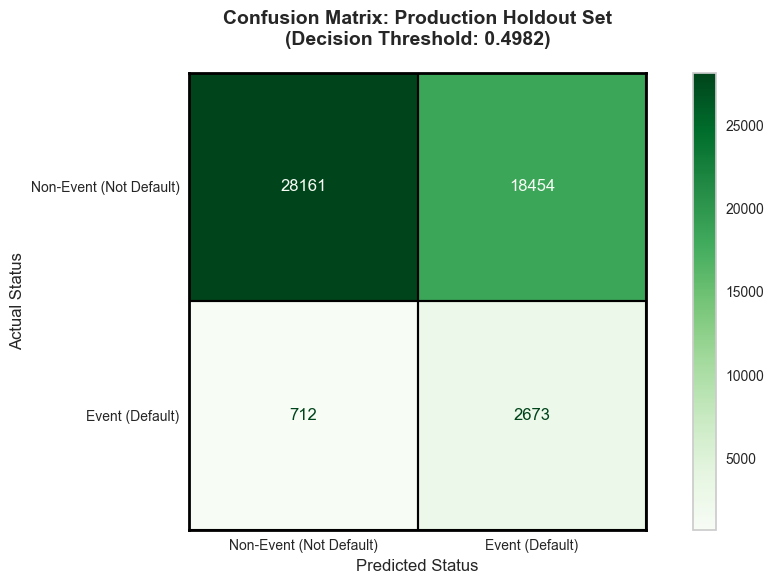

In [250]:
# Compute the confusion matrix array for the holdout set
cm_holdout = confusion_matrix(df_results["Loan Status"], df_results["PD_Prediction_Class"])

# Create the figure and axis object
fig, ax = plt.subplots(figsize=(10, 6))

# Display confusion matrix with green color map
disp = ConfusionMatrixDisplay(confusion_matrix=cm_holdout, display_labels=["Non-Event (Not Default)", "Event (Default)"])

# Plot the matrix
disp.plot(cmap="Greens", ax=ax, colorbar=True)

# Remove default grid
ax.grid(False)

# Add clean, dark internal borders around each cell quadrant
for i in range(cm_holdout.shape[0]):
    for j in range(cm_holdout.shape[1]):
        ax.add_patch(
            plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1.5))

# Apply a bold, strong outer bounding frame (spines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2) 
    spine.set_edgecolor("black")

# Formatting
plt.title(f"Confusion Matrix: Production Holdout Set\n(Decision Threshold: {youden_threshold:.4f})", pad=20, fontsize=14, fontweight="bold")
plt.xlabel("Predicted Status", fontsize=12)
plt.ylabel("Actual Status", fontsize=12)
ax.tick_params(axis="both", which="both", length=0)
plt.tight_layout()
plt.show()

Holdout Set ROC-AUC Score : 0.7627


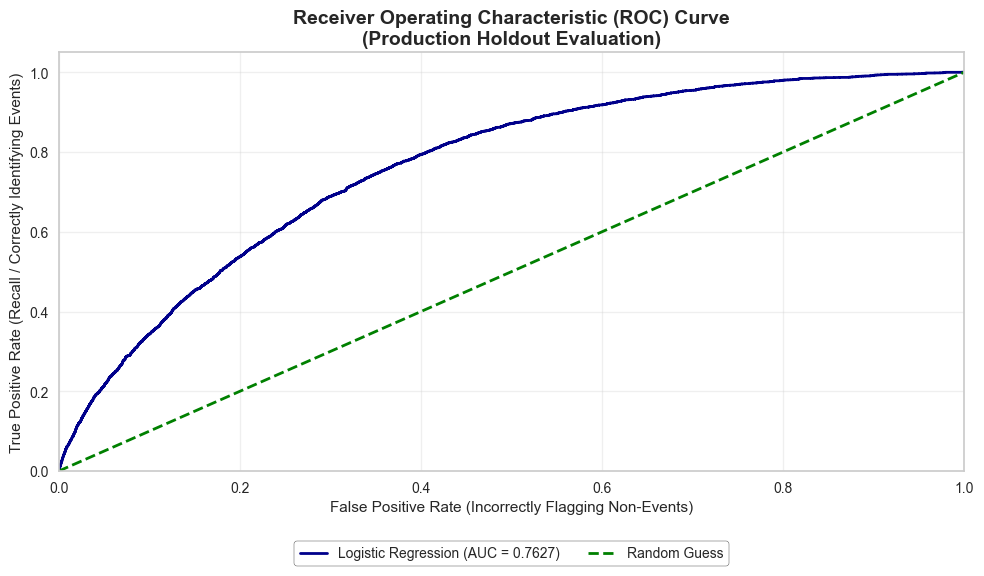

In [251]:
# Calculate the overall area under the curve using continuous probabilities
holdout_auc_score = roc_auc_score(df_results["Loan Status"], df_results["PD"])
print(f"Holdout Set ROC-AUC Score : {holdout_auc_score:.4f}")

# Calculate ROC Curve coordinates
holdout_fpr, holdout_tpr, holdout_thresholds = roc_curve(df_results["Loan Status"], df_results["PD"])

# Visualization logistic regression ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(holdout_fpr, holdout_tpr, color="darkblue", linewidth=2, label=f"Logistic Regression (AUC = {holdout_auc_score:.4f})",)

# Random Guess Reference Line
plt.plot([0, 1], [0, 1], linestyle="--", color="green", linewidth=2, label="Random Guess")

# Formatting
plt.title("Receiver Operating Characteristic (ROC) Curve\n(Production Holdout Evaluation)", fontsize=14, fontweight="bold",)
plt.xlabel("False Positive Rate (Incorrectly Flagging Non-Events)")
plt.ylabel("True Positive Rate (Recall / Correctly Identifying Events)")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fancybox=True, edgecolor="black",)
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

In [252]:
# PD Model Performance
# ----------------------------------------------------------------------------------------------------
holdout_auc_score = roc_auc_score(df_results["Loan Status"], df_results["PD"])

# Extract macro/event-specific metrics for the Default class (pos_label=1)
holdout_precision = precision_score(df_results["Loan Status"], df_results["PD_Prediction_Class"], pos_label=1)
holdout_recall = recall_score(df_results["Loan Status"], df_results["PD_Prediction_Class"], pos_label=1)
holdout_f1 = f1_score(df_results["Loan Status"], df_results["PD_Prediction_Class"], pos_label=1)

# LGD Model Performance (Isolate to Defaults Only)
# ----------------------------------------------------------------------------------------------------
df_defaults_eval = df_results[is_defaulted].copy()
actual_recovery_rate = (df_holdout.loc[is_defaulted, "recoveries"] - df_holdout.loc[is_defaulted, "collection_recovery_fee"]) / df_holdout.loc[is_defaulted, "funded_amnt"]
df_defaults_eval["Actual_LGD"] = (1.0 - actual_recovery_rate).clip(0.0, 1.0)
holdout_lgd_mae = mean_absolute_error(df_defaults_eval["Actual_LGD"], df_defaults_eval["LGD"])
holdout_lgd_rmse = np.sqrt(mean_squared_error(df_defaults_eval["Actual_LGD"], df_defaults_eval["LGD"]))

# EAD Model Performance (Isolate to Defaults Only)
# ----------------------------------------------------------------------------------------------------
actual_ead_amount = df_holdout.loc[is_defaulted, "funded_amnt"] - df_holdout.loc[is_defaulted, "total_rec_prncp"]
df_defaults_eval["Actual_EAD_Amount"] = actual_ead_amount.clip(lower=0.0)

# Convert the Actual Dollar EAD into an EAD FACTOR (Ratio between 0.0 and 1.0) to match the Test Set scale
df_defaults_eval["Actual_EAD_Factor"] = df_defaults_eval["Actual_EAD_Amount"] / df_defaults_eval["Funded Amount"]
df_defaults_eval["Actual_EAD_Factor"] = df_defaults_eval["Actual_EAD_Factor"].clip(0.0, 1.0)

# Compare 'Actual_EAD_Factor' against predicted 'EAD factor'
holdout_ead_mae = mean_absolute_error(df_defaults_eval["Actual_EAD_Factor"], df_defaults_eval["EAD factor"])
holdout_ead_rmse = np.sqrt(mean_squared_error(df_defaults_eval["Actual_EAD_Factor"], df_defaults_eval["EAD factor"]))

# Side-by-Side model comparision
# ------------------------------------------------------------------------------
performance_comparison = pd.DataFrame({
    "Risk Model Metric": ["PD Model: ROC-AUC", "PD Model: F1-Score", "PD Model: Recall", "PD Model: Precision", "LGD Model: MAE", "LGD Model: RMSE", "EAD Model: MAE", "EAD Model: RMSE"],
    "Test Set": [pd_roc, pd_f1, pd_recall, pd_precision, lgd_mae, lgd_rmse, ead_mae, ead_rmse],
    "Holdout Set": [holdout_auc_score, holdout_f1, holdout_recall, holdout_precision, holdout_lgd_mae, holdout_lgd_rmse, holdout_ead_mae, holdout_ead_rmse]})

performance_comparison["Absolute Difference"] = (performance_comparison["Holdout Set"] - performance_comparison["Test Set"]).abs()

print("\n📊 MODEL PERFORMANCE COMPARISON")
print("-" * 100)

display(performance_comparison.style.format({
        "Test Set": "{:.4f}",
        "Holdout Set": "{:.4f}",
        "Absolute Difference": "{:.4f}"}))


📊 MODEL PERFORMANCE COMPARISON
----------------------------------------------------------------------------------------------------


,Risk Model Metric,Test Set,Holdout Set,Absolute Difference
0,PD Model: ROC-AUC,0.7666,0.7627,0.0039
1,PD Model: F1-Score,0.2346,0.2181,0.0165
2,PD Model: Recall,0.7210,0.7897,0.0687
3,PD Model: Precision,0.1401,0.1265,0.0136
4,LGD Model: MAE,0.0461,0.0579,0.0119
5,LGD Model: RMSE,0.0570,0.0799,0.0229
6,EAD Model: MAE,0.0837,0.0817,0.0020
7,EAD Model: RMSE,0.1154,0.1100,0.0055


In [253]:
# Model Stability Assessment
# ----------------------------------------------------------------------------------------------------

pd_stable = abs(holdout_auc_score - pd_roc) <= 0.05
lgd_stable = (holdout_lgd_mae - lgd_mae) <= 0.05

stability_summary = pd.DataFrame({
    "Assessment": ["PD Stability Check", "LGD Stability Check", "Overall Model Status"],
    "Result": ["Stable" if pd_stable else "Not Stable", "Stable" if lgd_stable else "Not Stable", "PASS" if (pd_stable and lgd_stable) else "Performance Drift Detected"]})

print("\n🛡️ MODEL STABILITY ASSESSMENT")
print("-" * 100)
display(stability_summary)


🛡️ MODEL STABILITY ASSESSMENT
----------------------------------------------------------------------------------------------------


,Assessment,Result
0,PD Stability Check,Stable
1,LGD Stability Check,Stable
2,Overall Model Status,PASS


In [254]:
# Recall and Load the test set
sheet_target = "Scaled_Test_Data"
excel_filename = os.path.join(r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment", "X_test_encoded_output.xlsx")

try:
    print(f"🔄 Recalling scaled dataset from {excel_filename}...")
    # Read the explicit sheet name and preserve your continuous numerical scales
    X_test = pd.read_excel(excel_filename, sheet_name=sheet_target)
    print(f"✅ Data successfully loaded. Shape: {X_test.shape}")
    
    # Align and verify with loaded PD model artifact
    missing_feats = [col for col in pd_features if col not in X_test.columns]
    
    if missing_feats:
        print(f"⚠️ Warning: Missing expected model features in Excel file: {missing_feats}")
    else:
        print("🛡️ Feature Alignment Check: All required model features are present.")
        # Explicitly slice X_test to match the exact feature order the model was trained on
        X_test_aligned = X_test[pd_features]
        print(f"🎯 X_test successfully aligned to model feature signature. Shape: {X_test_aligned.shape}")

except FileNotFoundError:
    print(f"❌ Error: The file '{excel_filename}' could not be found.")
    print("👉 Check if the file is in your current working directory or specify the absolute path.")
except Exception as e:
    print(f"❌ An unexpected reading error occurred: {e}")

# Generate prediction for test set and holdout set for PSI testing
pd_test_proba = pd_model.predict_proba(X_test_aligned)[:, 1] # Test set
pd_holdout_proba = df_results["PD"] # Holdout set
print("✅ Probability generation completed. Ready for Population Stability Index (PSI) calculation.")

🔄 Recalling scaled dataset from C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment\X_test_encoded_output.xlsx...
✅ Data successfully loaded. Shape: (50000, 84)
🛡️ Feature Alignment Check: All required model features are present.
🎯 X_test successfully aligned to model feature signature. Shape: (50000, 84)
✅ Probability generation completed. Ready for Population Stability Index (PSI) calculation.


In [255]:
# BASEL-compliant PSI mathematical function
# ----------------------------------------------------------------------------------------------------
def calculate_psi(expected, actual, num_bins=10):
    """
    Calculates the Population Stability Index (PSI) between expected (test)
    and actual (holdout) continuous distributions using quantile bin intervals.
    """
    # Formulate bucket ranges using deciles calculated from the Expected baseline
    percentiles = np.linspace(0, 100, num_bins + 1)
    bins = np.percentile(expected, percentiles)
    
    # Adjust boundary limits to avoid boundary floating-point dropouts
    bins[0] -= 1e-5
    bins[-1] += 1e-5
    bins = np.unique(bins)
    actual_num_bins = len(bins) - 1

    # Allocate both populations into identical bucket paths
    expected_binned = pd.cut(expected, bins=bins, labels=False)
    actual_binned = pd.cut(actual, bins=bins, labels=False)

    # Map population frequency counts per bucket
    expected_counts = pd.Series(expected_binned).value_counts().reindex(range(actual_num_bins), fill_value=0)
    actual_counts = pd.Series(actual_binned).value_counts().reindex(range(actual_num_bins), fill_value=0)

    # Convert frequency distributions into fractional weights (proportions)
    expected_prop = expected_counts / len(expected)
    actual_prop = actual_counts / len(actual)

    # Apply minor count adjustments to secure against log(0) and division-by-zero errors
    expected_prop = np.where(expected_prop == 0, 1e-4, expected_prop)
    actual_prop = np.where(actual_prop == 0, 1e-4, actual_prop)

    # Standard Regulatory PSI Equation: Sum((Actual% - Expected%) * ln(Actual% / Expected%))
    psi_values = (actual_prop - expected_prop) * np.log(actual_prop / expected_prop)
    return np.sum(psi_values)


🛡️ POPULATION STABILITY INDEX (PSI) RISK ASSESSMENT
----------------------------------------------------------------------------------------------------


Metric,Status
PD Distribution Baseline Comparison,PSI Score = 0.0425
Regulatory Target Threshold Status,🟩 PASS: Stable


----------------------------------------------------------------------------------------------------


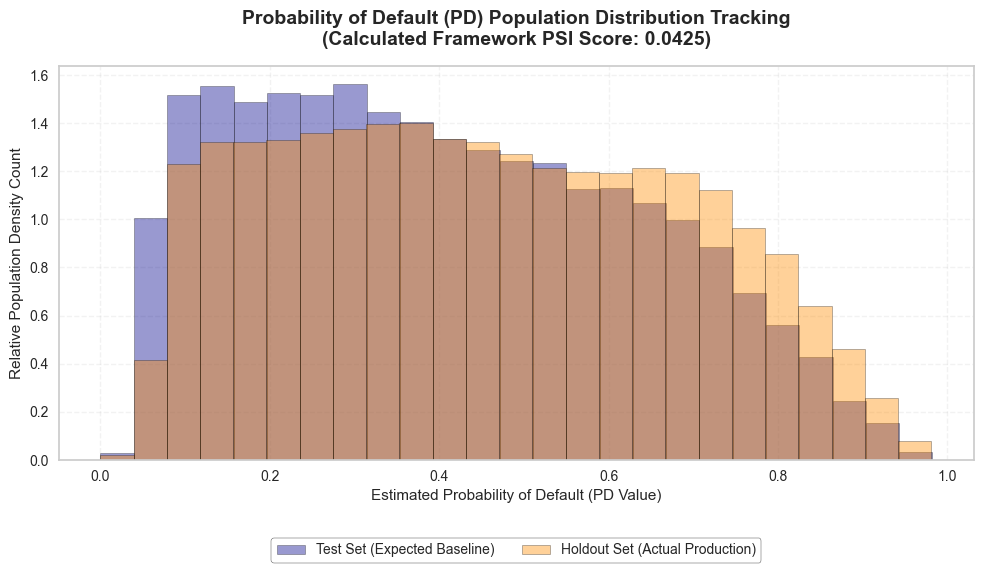

In [256]:
# Compute PSI and compare test set and holdout set
# ----------------------------------------------------------------------------------------------------
pd_psi_score = calculate_psi(pd_test_proba, pd_holdout_proba, num_bins=10)

# Establish Regulatory Threshold
if pd_psi_score < 0.10:
    psi_status = "🟩 PASS: Stable"
elif pd_psi_score < 0.25:
    psi_status = "🟨 WARNING: Moderate Population Drift"
else:
    psi_status = "🟥 ALERT: Severe Population Drift"

# Construct DataFrame
psi_results_df = pd.DataFrame({
    "Metric": ["PD Distribution Baseline Comparison", "Regulatory Target Threshold Status"],
    "Status": [f"PSI Score = {pd_psi_score:.4f}", psi_status,]})

print("\n🛡️ POPULATION STABILITY INDEX (PSI) RISK ASSESSMENT")
print("-" * 100)
# Using style configuration to handle clean string alignment wrap rules
display(psi_results_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))
print("-" * 100)

# ==============================================================================
# VISUALIZATION: DUAL POPULATION DENSITY DISTRIBUTION CHART VisualizationL Dual population density distribution chart
# ==============================================================================
plt.figure(figsize=(10, 6))
# Generate overlaid histograms with continuous density distributions
plt.hist(pd_test_proba, bins=25, alpha=0.4, color="darkblue", label="Test Set (Expected Baseline)", density=True, edgecolor='black', linewidth=0.5)
plt.hist(pd_holdout_proba, bins=25, alpha=0.4, color="darkorange", label="Holdout Set (Actual Production)", density=True, edgecolor='black', linewidth=0.5)

# Configuration
plt.title(f"Probability of Default (PD) Population Distribution Tracking\n(Calculated Framework PSI Score: {pd_psi_score:.4f})", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Estimated Probability of Default (PD Value)", fontsize=11)
plt.ylabel("Relative Population Density Count", fontsize=11)
plt.grid(alpha=0.25, linestyle='--')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True, fancybox=True, edgecolor="black")

# Compress margins and secure explicit clearance for the bottom legend setup
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

# Saving notebook

In [257]:
import shutil

# Define source and destination
current_notebook_name = "N04 – Holdout Validation and Model Performance Assessment.ipynb" 
destination_path = r"C:\Users\danie\Downloads\Data Analytic\lending_club_data\model_deployment"

# Ensure destination exists
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

# Perform the copy
try:
    # This looks for the file in the current working directory
    shutil.copy(current_notebook_name, os.path.join(destination_path, current_notebook_name))
    print(f"✅ Notebook successfully copied to: {destination_path}")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{current_notebook_name}'.")
    print("👉 Make sure the filename matches exactly and you have saved (Ctrl+S) recently.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

❌ An unexpected error occurred: 'N04 – Holdout Validation and Model Performance Assessment.ipynb' and 'C:\\Users\\danie\\Downloads\\Data Analytic\\lending_club_data\\model_deployment\\N04 – Holdout Validation and Model Performance Assessment.ipynb' are the same file
